In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm
from torchvision import datasets
from sklearn.model_selection import train_test_split


In [2]:
class SGD:
    def __init__(self, lr: float = 1e-3, beta1: float = 0.9, weight_decay: float = 0):
        self.lr = lr
        self.beta1 = beta1
        self.weight_decay = weight_decay

        self.m = []

    def step(self, params: list[np.ndarray], grads: list[np.ndarray]) -> list[np.ndarray]:
        for i, (param, grad) in enumerate(zip(params, grads)):
            if len(self.m) != len(params):
                self.m.append(np.zeros_like(param))

            m = self.m[i]
            m = self.beta1 * m + (1 - self.beta1) * m

            param_new = (param - self.lr * m - self.lr * self.weight_decay * param)
            self.m[i] = m
            params[i] = param_new

        return params

In [3]:
class RMSprop:
    def __init__(self, lr: float = 1e-3, beta2: float = 0.999, eps: float = 1e-8, weight_decay: float = 0):
        self.lr = lr
        self.beta2 = beta2
        self.eps = eps
        self.weight_decay = weight_decay

        self.v = []

    def step(self, params: list[np.ndarray], grads: list[np.ndarray]) -> list[np.ndarray]:
        for i, (param, grad) in enumerate(zip(params, grads)):

            if len(self.v) != len(params):
                self.v.append(np.zeros_like(param))

            v = self.v[i]
            v = self.beta2 * v + (1 - self.beta2) * np.square(grad)

            lr_step = self.lr / (np.sqrt(v) + self.eps)
            new_param = param - lr_step * grad - self.lr * self.weigth_decay * param

            self.v[i] = v
            params[i] = new_param

        return params

In [4]:
class AdamW:
    def __init__(self, lr: float = 1e-3, beta1: float = 0.9, beta2: float = 0.999, eps: float = 1e-8, weight_decay: float = 0):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.weight_decay = weight_decay
        self.t = 0

        self.m = []
        self.v = []

    def step(self, params: list[np.ndarray], grads: list[np.ndarray]) -> list[np.ndarray]:
        self.t += 1

        for i, (param, grad) in enumerate(zip(params, grads)):
            if len(self.v) != len(params):
                self.m.append(np.zeros_like(param))
                self.v.append(np.zeros_like(param))

            m = self.beta1 * self.m[i] + (1 - self.beta1) * grad
            v = self.beta2 * self.v[i] + (1 - self.beta2) * np.square(grad)

            m_hat = m / (1 - self.beta1** self.t)
            v_hat = v / (1 - self.beta2** self.t)

            adam_step = m_hat/(np.sqrt(v_hat) + self.eps)
            param_new = param - self.lr * adam_step - self.lr * self.weight_decay * param

            self.v[i] = v
            self.m[i] = m
            params[i] = param_new

        return params

In [5]:
def load_mnist_simple(
    train: bool = True,
    root: str = "./data",
) -> tuple[np.ndarray, np.ndarray]:
    num_class = 10
    dataset = datasets.MNIST(
        root=root,
        train=train,
        download=True
    )

    images = np.stack([img for img, _ in dataset])
    images = images.astype(np.uint8)

    labels = np.array([label for _, label in dataset])
    one_hot = np.eye(num_class)[labels]

    return images, one_hot

def label_to_onehot(label: int, num_class: int = 10) -> np.ndarray:
    one_hot = np.zeros(num_class)
    one_hot[label] = 1
    return one_hot


def onehot_to_label(one_hot: np.ndarray) -> np.ndarray:
    return np.argmax(one_hot)

def to_label(pred_bs: np.ndarray) -> np.ndarray:
    return np.argmax(pred_bs, axis=-1)


In [6]:
class CrossEntropyLoss:

    def forward(self, pred: np.ndarray, target: np.ndarray) -> float:
        self.batch_size = pred.shape[0]
        self.target = target

        logits_max = pred.max(axis=1, keepdims=True)
        exp_pred = np.exp(pred - logits_max)

        self.softmax = exp_pred / exp_pred.sum(axis=1, keepdims=True)

        log_sum_exp = np.log(exp_pred.sum(axis=1, keepdims=True))
        loss = (-np.sum(target * pred, axis=1, keepdims=True) + logits_max + log_sum_exp)

        return loss.mean()

    def backward(self) -> np.ndarray:
        return (self.softmax - self.target) / self.batch_size

    def __call__(self, pred: np.ndarray, target: np.ndarray) -> float:
        return self.forward(pred, target)

In [32]:
class Dropout:
    def __init__(self, p: float=0.5, train=True):
        self.p = p
        self.training = train
        self.scale = 1/ (1 - self.p)

    def forward(self, x: np.ndarray) -> np.ndarray:
        if not self.training:
            return x

        self.mask = (np.random.rand(*x.shape) > self.p)
        return x * self.mask * self.scale

    def backward(self, grad_output: np.ndarray) -> np.ndarray:
        return grad_output * self.mask * self.scale

    def __call__(self, x: np.ndarray) -> np.ndarray:
        return self.forward(x)

In [7]:
def relu(x: np.ndarray) -> np.ndarray:
    return np.maximum(0, x)

def drelu(act: np.ndarray, grad: np.ndarray) -> np.ndarray:
    return grad * np.where(act > 0, 1, 0)

def softmax(x : np.ndarray) -> np.ndarray:
    max_x = np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x - max_x)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

In [ ]:
def normalize(sample: np.ndarray) -> np.ndarray:
    s_min = np.min(sample, axis=-1, keepdims=True)
    s_max = np.max(sample, axis=-1, keepdims=True)
    return (sample - s_min) / (s_max - s_min) *2 - 1

def initialization_params(size: tuple[int, int], mode: str="normal", seed: int=None, empas: str="in") -> np.ndarray:
    rng = np.random.default_rng(seed)
    n_in, n_out = size
    gain = np.sqrt(2)

    if mode == 'normal':
        return rng.standard_normal(size=size)

    elif mode == "xavier_normal":
        std = gain * np.sqrt(2.0 / (n_in + n_out))
        return rng.normal(0, std, size=size)

    elif mode == "xavier_uniform":
        bound = gain * np.sqrt(6.0 / (n_in + n_out))
        return rng.uniform(-bound, bound, size=size)

    elif mode == "kaiming_normal":
        std = gain * np.sqrt(1.0 / (n_in if empas=="in" else n_out))
        return rng.normal(0, std, size=size)

    elif mode == "kaiming_uniform":
        bound = gain * np.sqrt(3.0 / (n_in if empas=="in" else n_out))
        return rng.uniform(-bound, bound, size=size)
    else:
        raise ValueError("Данный тип инициализации весов еще не был введен")

def create_layers(n_input: int, n_output: int, mode: str="normal", seed: int=None, n_hidden: int=128) -> tuple[np.ndarray, ...]:
    W1 = initialization_params(size=(n_input, n_hidden), mode=mode, seed=seed)
    b1 = initialization_params(size=(1, n_hidden), mode=mode, seed=seed)

    W2 = initialization_params(size=(n_hidden, n_output), mode=mode, seed=seed)
    b2 = initialization_params(size=(1, n_output), mode=mode, seed=seed)
    return (W1, b1, W2, b2)

def data_loader(data: tuple[np.ndarray, np.ndarray], n_input: int, n_output: int, batch_size: int, epoch: int, shuffle: bool = False, seed: int = None):
    imgs, targets = data
    data_size = imgs.shape[0]
    num_batches = data_size // batch_size
    total = batch_size * num_batches

    if shuffle:
        rng = np.random.default_rng(seed + epoch if epoch else 0)
        idx = rng.permutation(data_size)
        imgs, targets = imgs[idx], targets[idx]

    imgs_batches = imgs[:total].reshape(num_batches, batch_size, n_input)
    targets_batches = targets[:total].reshape(num_batches, batch_size, n_output)

    return imgs_batches, targets_batches
    

In [40]:
def train(
        data: tuple[np.ndarray, np.ndarray],
        opt,
        loss_model,
        n_input: int,
        n_hidden: int,
        n_output: int,
        mode: str= "normal",
        batch_size: int= 16,
        epochs: int= 1,
        lr: float= 0.01,
        shuffle: bool = False,
        norm = False,
        seed = None,
):
    train_data, val_data = data["train"], data["val"]
    W1, b1, W2, b2 = create_layers(n_input, n_output, mode=mode, seed=seed, n_hidden=n_hidden)
    dropout = Dropout()

    train_acc_history = []
    train_loss_history = []
    val_acc_history = []
    val_loss_history = []

    loop = tqdm(range(epochs), leave=False)
    for epoch in loop:
        if epoch == 26:
              opt.lr = 1e-4
        imgs_batches, targets_batches = data_loader(train_data, n_input, n_output, batch_size, epoch, shuffle=shuffle, seed=seed)

        if norm:
                imgs_batches = normalize(imgs_batches)

        train_loader = (imgs_batches, targets_batches)

        correct, total = 0, 0
        batch_losses = []

        for i, (imgs_batch, target) in enumerate(zip(*train_loader)):
               out1 = imgs_batch @ W1 + b1
               act1 = relu(out1)
               drop = dropout(act1)

               pred = drop @ W2 + b2
               loss = loss_model(pred, target)
               batch_losses.append(loss)

               dpred = loss_model.backward()
               db2 = np.sum(dpred, axis=0, keepdims=True)
               dW2 = drop.T @ dpred
               ddrop = dpred @ W2.T

               dact1 = dropout.backward(ddrop)
               dout1 = drelu(act1, dact1)

               db1 = np.sum(dout1, axis=0, keepdims=True)
               dW1 = imgs_batch.T @ dout1

               params = [W2, b2, W1, b1]
               grads = [dW2, db2, dW1, db1]
               W2, b2, W1, b1 = opt.step(params, grads)

               target_label = to_label(target)
               pred_label = to_label(pred)
               correct += (pred_label == target_label).sum().item()
               total += target_label.size

               if i % 10 == 0:
                   loop.set_description(f"Epoch [{epoch+1}/{epochs}], train_loss = {loss:.4f}") 

        train_acc = correct/total
        train_loss = np.mean(batch_losses).item()
        train_acc_history.append(train_acc)
        train_loss_history.append(train_loss)

        imgs_batches, targets_batches = data_loader(val_data, n_input, n_output, batch_size, epoch, shuffle=False, seed=seed)
        
        if norm:
                imgs_batches = normalize(imgs_batches)

        train_loader = (imgs_batches, targets_batches)

        correct, total = 0, 0
        batch_losses = []
    
        for i, (imgs_batch, target) in enumerate(zip(*train_loader)):
            out1 = imgs_batch @ W1 + b1
            act1 = relu(out1)

            pred = act1 @ W2 + b2
            loss = loss_model(pred, target)
            batch_losses.append(loss)
            target_label = to_label(target)
            pred_label = to_label(pred)
            correct += (pred_label == target_label).sum().item()
            total += target_label.size

        val_acc = correct / total
        val_loss = np.mean(batch_losses).item()
        val_acc_history.append(val_acc)
        val_loss_history.append(val_loss)        
        print(f"Epoch [{epoch+1}/{epochs}], train_loss = {train_loss:.4f}, val_loss = {val_loss:.4f}")

    print(f"\nПосле {epoch+1} эпох обучения:")
    print(f"\ttrain_loss = {train_loss:.4f}, train_acc = {train_acc:.4f}")
    print(f"\tval_loss   = {val_loss:.4f}, val_acc   = {val_acc:.4f}")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

    ax1.plot(train_loss_history, label=f'train')
    ax1.plot(val_loss_history, label=f'val')
    ax1.set_title('Loss')
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)

    ax2.plot(train_acc_history, label=f'train')
    ax2.plot(val_acc_history, label=f'val')
    ax2.set_title('Accuracy')
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)

    plt.show()

    return W1, b1, W2, b2


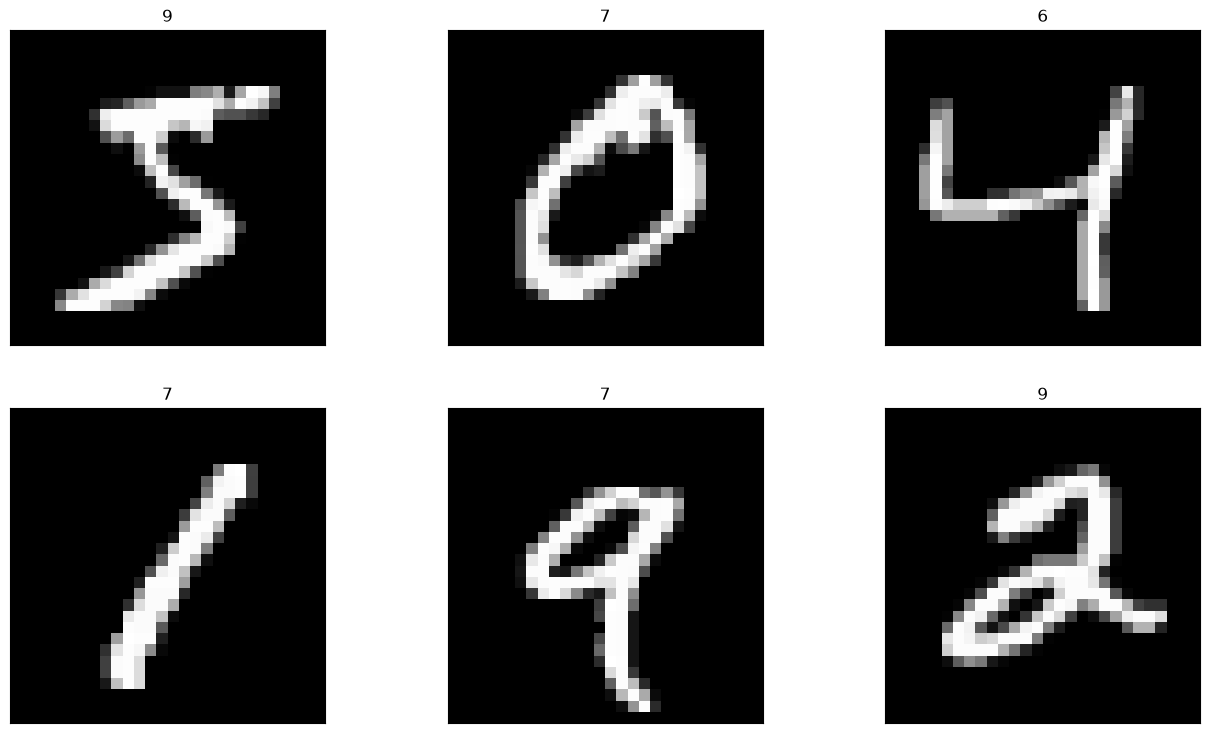

In [37]:
imgs, targets = load_mnist_simple()

row = 2
col = 3

idxs = np.random.randint(0, 60000, row*col)
fig, ax = plt.subplots(row, col, figsize=(16,9))
ax = ax.flatten()

for i, idx in enumerate(idxs):
    ax[i].imshow(imgs[i], cmap="grey")
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    ax[i].set_title(f"{np.argmax(targets[idx])}")

  0%|          | 0/40 [00:00<?, ?it/s]

Epoch [1/40], train_loss = 0.5570, val_loss = 0.2287
Epoch [2/40], train_loss = 0.3228, val_loss = 0.1831
Epoch [3/40], train_loss = 0.2778, val_loss = 0.1671
Epoch [4/40], train_loss = 0.2446, val_loss = 0.1479
Epoch [5/40], train_loss = 0.2239, val_loss = 0.1296
Epoch [6/40], train_loss = 0.2153, val_loss = 0.1313
Epoch [7/40], train_loss = 0.2015, val_loss = 0.1266
Epoch [8/40], train_loss = 0.1970, val_loss = 0.1156
Epoch [9/40], train_loss = 0.1855, val_loss = 0.1143
Epoch [10/40], train_loss = 0.1777, val_loss = 0.1126
Epoch [11/40], train_loss = 0.1703, val_loss = 0.1069
Epoch [12/40], train_loss = 0.1679, val_loss = 0.1090
Epoch [13/40], train_loss = 0.1644, val_loss = 0.1000
Epoch [14/40], train_loss = 0.1631, val_loss = 0.1105
Epoch [15/40], train_loss = 0.1605, val_loss = 0.1030
Epoch [16/40], train_loss = 0.1539, val_loss = 0.1138
Epoch [17/40], train_loss = 0.1503, val_loss = 0.1063
Epoch [18/40], train_loss = 0.1484, val_loss = 0.1003
Epoch [19/40], train_loss = 0.1431, v

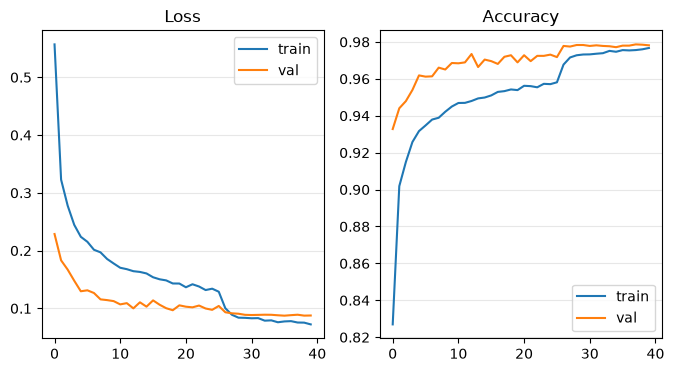

In [41]:
seed = 1961

t_img, test_img, t_target, test_target = train_test_split(imgs, targets, test_size=0.1, random_state=seed, stratify=np.argmax(targets,axis=1))

train_img, val_img, train_target, val_target = train_test_split(t_img, t_target, test_size=0.111, random_state=seed, stratify=np.argmax(t_target,axis=1))

train_data = {"train" : (train_img, train_target), "val": (val_img, val_target)}

loss_model = CrossEntropyLoss()
opt = AdamW()

W1, b1, W2, b2 = train(train_data, opt, loss_model, 28*28, 256, 10, mode="xavier_uniform", batch_size=64, epochs=40, shuffle=True, norm=True, seed=seed)

In [42]:
imgs_batches, targets_batches = data_loader((test_img, test_target), 28*28, 10, 64, 1, False, seed=seed)

imgs_batches = normalize(imgs_batches)

correct = 0
total = 0
batch_losses = []

for i, (imgs_batch, targets_batch) in enumerate(zip(imgs_batches, targets_batches)):
    out1 = imgs_batch @ W1 + b1
    act1 = relu(out1)
    pred = act1 @ W2 + b2
    loss = loss_model(pred, targets_batch)
    batch_losses.append(loss)

    target_label = to_label(targets_batch)
    pred_label = to_label(pred)
    correct += (pred_label == target_label).sum().item()
    total += target_label.size

test_acc = correct/total
test_loss = np.mean(batch_losses).item()
print(f"Качество сети на тестовой выборке:")
print(f"\ttest_loss = {test_loss:.4f}, test_acc = {test_acc:.4f}")

Качество сети на тестовой выборке:
	test_loss = 0.0956, test_acc = 0.9756
